In [81]:
# Configuración para visualización en PDF
import pandas as pd
import numpy as np
import sys

# Para que el texto de pandas no se corte
pd.set_option('display.max_colwidth', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)  # Ancho fijo para pandas

# Para prints largos de numpy - ancho más conservador
np.set_printoptions(linewidth=100, edgeitems=3)

# Configurar ancho de terminal para prints
import os
os.environ['COLUMNS'] = '100'

print(" Configuración para PDF lista")

 Configuración para PDF lista


### 1. Setup e Imports

In [ ]:
import numpy as np
import torch
import sys
import os
from pathlib import Path
from tqdm import tqdm
import time

# Configurar paths
project_root = Path('../../..').resolve()
sys.path.insert(0, str(project_root))

from sae.models.sae import SparseAutoencoder
from sae.tools.naming_utils import get_checkpoint_dir, get_model_name, get_extras_id
from sae.tools.experiment_utils import get_experiment_dir, get_metrics_dir, get_report_name

# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memoria disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

Device: cuda
GPU: NVIDIA GeForce RTX 5060
Memoria disponible: 8.55 GB


In [83]:
# Metadata del experimento (debe coincidir con el notebook de entrenamiento)
NAMING_META = {
    'variante': 'standard',          # Arquitectura del SAE
    'tecnica': 'p-annealing',                 # Técnica de sparsity
    'capa': 6,                       # Layer del modelo OthelloGPT
    'juegos': 200,                  # Número de partidas
    'base_path': 'C:\\Users\\Esposa\\Documents\\Repos\\sae-othello-gpt',  # Path base para checkpoints
    'experiment_base_path': os.path.abspath('../../experiments'),          # sae/experiments/
    'extras': {
        'expansion': 16,
        'lambda': 0.0,
        'nuevo': 4.0
    }
}

print('\n Metadata del experimento:')
for key, value in NAMING_META.items():
    print(f'  {key}: {value}')


 Metadata del experimento:
  variante: standard
  tecnica: p-annealing
  capa: 6
  juegos: 200
  base_path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt
  experiment_base_path: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments
  extras: {'expansion': 16, 'lambda': 0.0, 'nuevo': 4.0}


### 2. Cargar Datos

In [ ]:
# Cargar activaciones pre-SAE
activations_path = project_root / "sae" / "activations" / "data" / "layer5_200games.npy"
activations = np.load(activations_path)

print(f"Activaciones del modelo:")
print(f"  Shape: {activations.shape}")
print(f"  Memoria: {activations.nbytes / (1024**2):.2f} MB")

Activaciones del modelo:
  Shape: (11800, 512)
  Memoria: 23.05 MB


In [85]:
# Cargar ground truth de BSPs
bsp_gt_path = project_root / "sae" / "metrics" / "02_data" / "bsp_ground_truth_200games.npy"
bsp_names_path = project_root / "sae" / "metrics" / "02_data" / "bsp_ground_truth_200games.names.npy"

bsp_ground_truth = np.load(bsp_gt_path)
bsp_names = np.load(bsp_names_path, allow_pickle=True)

print(f"\nGround truth BSPs:")
print(f"  Shape: {bsp_ground_truth.shape}")
print(f"  Total BSPs: {len(bsp_names)}")


Ground truth BSPs:
  Shape: (11800, 326)
  Total BSPs: 326


### 3. Cargar SAE y Extraer Features

In [86]:
# Configuración del SAE
input_dim = 512
hidden_dim = 16384

# Construir ruta del modelo usando naming_utils
checkpoint_dir = get_checkpoint_dir(
    NAMING_META['base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos']
)
extras_id = get_extras_id(checkpoint_dir, NAMING_META['extras']) if NAMING_META.get('extras') else None

model_name = get_model_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'best',
    extras_id=extras_id
)
model_path = checkpoint_dir / model_name

# Cargar modelo (weights_only=False: checkpoint contiene objetos Path en config)
sae = SparseAutoencoder(input_dim, hidden_dim).to(device)
checkpoint = torch.load(model_path, map_location=device, weights_only=False)
sae.load_state_dict(checkpoint['model_state_dict'])
sae.eval()

print(f"SAE cargado:")
print(f"  Path: {model_path}")
print(f"  Input: {input_dim}, Hidden: {hidden_dim}")
print(f"  Expansion: {hidden_dim/input_dim}x")
print(f"  Epoch: {checkpoint.get('epoch', 'N/A')}, Val MSE: {checkpoint.get('val_mse', float('nan')):.6f}")

SAE cargado:
  Path: C:\Users\Esposa\Documents\Repos\sae-othello-gpt\layer_06\models\sae_standard\sae_p-annealing_standard\200games\sae_standard_p-annealing_l6_200g_ex4_best.pt
  Input: 512, Hidden: 16384
  Expansion: 32.0x
  Epoch: N/A, Val MSE: nan


In [87]:
# Extraer features del SAE en GPU
print("Extrayendo features del SAE...")
activations_tensor = torch.from_numpy(activations).float().to(device)

with torch.no_grad():
    sae_features = torch.relu(sae.encoder(activations_tensor))

print(f"\nFeatures SAE:")
print(f"  Shape: {sae_features.shape}")
print(f"  Device: {sae_features.device}")
print(f"  Sparsity: {(sae_features == 0).float().mean():.2%}")
print(f"  Activaciones promedio: {(sae_features > 0).sum(dim=1).float().mean():.1f}")

Extrayendo features del SAE...

Features SAE:
  Shape: torch.Size([11800, 16384])
  Device: cuda:0
  Sparsity: 96.30%
  Activaciones promedio: 606.0


### 4. Filtrar BSPs de Piezas

Coverage solo usa las 128 BSPs de piezas (mías/oponente), sin vacías.

In [88]:
# =============================================
# CONFIGURACIÓN DE FILTRADO DE BSPs
# =============================================
USE_PLAYER   = False   # BSPs perspectiva del jugador (1 y 2)
USE_ABSOLUTE = True  # BSPs absolutas negro/blanco (B y W)
USE_STRATEGIC = False # BSPs especiales (BSP_)

# Filtrar según configuración
bsp_pieces_indices = []
bsp_pieces_names = []

for i, name in enumerate(bsp_names):
    include = False
    
    if USE_PLAYER and len(name) == 6 and name.startswith('BSP') and (name.endswith('1') or name.endswith('2')):
        include = True
    if USE_ABSOLUTE and (name.endswith('B') or name.endswith('W')):
        include = True
    if USE_STRATEGIC and name.startswith('BSP_'):
        include = True
    
    if include:
        bsp_pieces_indices.append(i)
        bsp_pieces_names.append(name)

bsp_pieces_indices = np.array(bsp_pieces_indices)
bsp_pieces_gt = bsp_ground_truth[:, bsp_pieces_indices]

# Convertir a tensor en GPU
bsp_pieces_gt_tensor = torch.from_numpy(bsp_pieces_gt).bool().to(device)

print(f"BSPs seleccionadas para Coverage:")
print(f"  Player: {USE_PLAYER} | Absolute: {USE_ABSOLUTE} | Strategic: {USE_STRATEGIC}")
print(f"  Total: {len(bsp_pieces_indices)}")
print(f"  Shape: {bsp_pieces_gt_tensor.shape}")
print(f"  Device: {bsp_pieces_gt_tensor.device}")
print(f"  Primeras 5: {', '.join(bsp_pieces_names[:5])}")
print(f"  Últimas 5: {', '.join(bsp_pieces_names[-5:])}")

BSPs seleccionadas para Coverage:
  Player: False | Absolute: True | Strategic: False
  Total: 128
  Shape: torch.Size([11800, 128])
  Device: cuda:0
  Primeras 5: BSPA1B, BSPA1W, BSPA2B, BSPA2W, BSPA3B
  Últimas 5: BSPH6W, BSPH7B, BSPH7W, BSPH8B, BSPH8W


### 5. Implementación de Coverage

#### Estrategia de optimización:
1. **Vectorización**: Procesar múltiples features en paralelo usando operaciones matriciales
2. **Batch processing**: Dividir en chunks para no saturar memoria GPU
3. **Pre-cálculo**: Calcular máximos una sola vez
4. **Early stopping**: Terminar cuando F1 ≈ 1.0

In [89]:
def fast_f1_score_gpu(y_true, y_pred, eps=1e-8):
    """
    F1 score vectorizado en GPU.
    
    Args:
        y_true: Tensor (n_positions,) booleano
        y_pred: Tensor (n_positions, n_candidates) booleano
    
    Returns:
        f1_scores: Tensor (n_candidates,)
    """
    # y_true: (n_positions,) -> expand to (n_positions, 1)
    y_true_expanded = y_true.unsqueeze(1)  # (n_positions, 1)
    
    # Calcular TP, FP, FN
    tp = (y_true_expanded & y_pred).sum(dim=0).float()  # (n_candidates,)
    fp = (~y_true_expanded & y_pred).sum(dim=0).float()
    fn = (y_true_expanded & ~y_pred).sum(dim=0).float()
    
    # Precision y Recall
    precision = tp / (tp + fp + eps)
    recall = tp / (tp + fn + eps)
    
    # F1
    f1 = 2 * (precision * recall) / (precision + recall + eps)
    
    return f1


def calculate_coverage_gpu_optimized(
    sae_features,  # Tensor (n_positions, n_features) en GPU
    bsp_ground_truth,  # Tensor (n_positions, n_bsps) en GPU, bool
    thresholds=[0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
    batch_size_features=512,  # Procesar 512 features a la vez
    verbose=True
):
    """
    Calcula Coverage de forma optimizada para GPU.
    
    Procesa múltiples features y thresholds en paralelo usando operaciones matriciales.
    """
    n_positions, n_features = sae_features.shape
    n_bsps = bsp_ground_truth.shape[1]
    n_thresholds = len(thresholds)
    
    if verbose:
        print("="*60)
        print("CALCULATING COVERAGE (GPU OPTIMIZED)")
        print("="*60)
        print(f"Positions: {n_positions:,}")
        print(f"SAE Features: {n_features:,}")
        print(f"BSPs: {n_bsps}")
        print(f"Thresholds: {n_thresholds}")
        print(f"Batch size (features): {batch_size_features}")
        print(f"Total evaluations: {n_bsps * n_features * n_thresholds:,}")
        print("="*60)
    
    # Pre-calcular máximos de features
    f_max = sae_features.max(dim=0)[0]  # (n_features,)
    active_features = (f_max > 0).nonzero(as_tuple=True)[0]
    n_active = len(active_features)
    
    if verbose:
        print(f"\nActive features: {n_active:,}/{n_features:,} ({n_active/n_features*100:.1f}%)")
        print(f"Reduced evaluations: {n_bsps * n_active * n_thresholds:,}")
        print()
    
    # Almacenar resultados
    best_f1s = torch.zeros(n_bsps, device=sae_features.device)
    best_features = torch.full((n_bsps,), -1, dtype=torch.long, device=sae_features.device)
    best_thresholds = torch.full((n_bsps,), -1.0, device=sae_features.device)
    
    thresholds_tensor = torch.tensor(thresholds, device=sae_features.device)
    
    # Procesar cada BSP
    pbar = tqdm(range(n_bsps), desc="Processing BSPs") if verbose else range(n_bsps)
    
    for bsp_idx in pbar:
        bsp_labels = bsp_ground_truth[:, bsp_idx]  # (n_positions,)
        
        # Skip si la BSP nunca está activa
        if not bsp_labels.any():
            continue
        
        # Procesar features activas en batches
        for batch_start in range(0, n_active, batch_size_features):
            batch_end = min(batch_start + batch_size_features, n_active)
            batch_features_idx = active_features[batch_start:batch_end]
            
            # Extraer features del batch
            batch_activations = sae_features[:, batch_features_idx]  # (n_positions, batch_size)
            batch_f_max = f_max[batch_features_idx]  # (batch_size,)
            
            # Para cada threshold, binarizar TODAS las features del batch a la vez
            for t in thresholds_tensor:
                # Binarizar: (n_positions, batch_size)
                predictions = batch_activations > (t * batch_f_max.unsqueeze(0))
                
                # Calcular F1 para todas las features del batch
                f1_scores = fast_f1_score_gpu(bsp_labels, predictions)  # (batch_size,)
                
                # Encontrar la mejor en este batch
                max_f1, max_idx_in_batch = f1_scores.max(dim=0)
                
                # Actualizar si es mejor que lo visto hasta ahora
                if max_f1 > best_f1s[bsp_idx]:
                    best_f1s[bsp_idx] = max_f1
                    best_features[bsp_idx] = batch_features_idx[max_idx_in_batch]
                    best_thresholds[bsp_idx] = t
            
            # Early stopping: si ya es casi perfecto, no revisar más batches
            if best_f1s[bsp_idx] >= 0.999:
                break
    
    # Calcular Coverage (macro-average)
    coverage = best_f1s.mean().item()
    
    # Convertir a CPU para retornar
    best_f1s_cpu = best_f1s.cpu().numpy()
    best_features_cpu = best_features.cpu().numpy()
    best_thresholds_cpu = best_thresholds.cpu().numpy()
    
    return coverage, best_f1s_cpu, best_features_cpu, best_thresholds_cpu

print(" Funciones de Coverage GPU definidas")

 Funciones de Coverage GPU definidas


### 6. Calcular Coverage

In [90]:
# Medir tiempo de ejecución
start_time = time.time()

coverage, best_f1s, best_features, best_thresholds = calculate_coverage_gpu_optimized(
    sae_features,
    bsp_pieces_gt_tensor,
    batch_size_features=512,  # Ajustar según memoria GPU
    verbose=True
)

elapsed_time = time.time() - start_time

print("\n" + "="*60)
print("RESULTADO COVERAGE")
print("="*60)
print(f"Coverage Score: {coverage:.4f}")
print(f"Objetivo (paper): 0.52")
print(f"Diferencia: {coverage - 0.52:+.4f}")
print(f"\nTiempo de ejecución: {elapsed_time:.2f} seg")
print(f"                      ({elapsed_time/60:.2f} min)")
print("="*60)

CALCULATING COVERAGE (GPU OPTIMIZED)
Positions: 11,800
SAE Features: 16,384
BSPs: 128
Thresholds: 10
Batch size (features): 512
Total evaluations: 20,971,520

Active features: 16,321/16,384 (99.6%)
Reduced evaluations: 20,890,880



Processing BSPs: 100%|██████████| 128/128 [00:51<00:00,  2.47it/s]


RESULTADO COVERAGE
Coverage Score: 0.3817
Objetivo (paper): 0.52
Diferencia: -0.1383

Tiempo de ejecución: 51.81 seg
                      (0.86 min)


### 7. Análisis de Resultados

In [91]:
# Estadísticas de distribución de F1 scores
print("Distribución de F1 scores:")
print(f"  Mínimo: {best_f1s.min():.4f}")
print(f"  Máximo: {best_f1s.max():.4f}")
print(f"  Media: {best_f1s.mean():.4f}")
print(f"  Mediana: {np.median(best_f1s):.4f}")
print(f"  Std: {best_f1s.std():.4f}")
print()
print(f"BSPs con F1 > 0.8: {(best_f1s > 0.8).sum()} ({(best_f1s > 0.8).mean()*100:.1f}%)")
print(f"BSPs con F1 > 0.5: {(best_f1s > 0.5).sum()} ({(best_f1s > 0.5).mean()*100:.1f}%)")
print(f"BSPs con F1 < 0.2: {(best_f1s < 0.2).sum()} ({(best_f1s < 0.2).mean()*100:.1f}%)")

Distribución de F1 scores:
  Mínimo: 0.2762
  Máximo: 0.4919
  Media: 0.3817
  Mediana: 0.3812
  Std: 0.0500

BSPs con F1 > 0.8: 0 (0.0%)
BSPs con F1 > 0.5: 0 (0.0%)
BSPs con F1 < 0.2: 0 (0.0%)


In [92]:
# Top 10 BSPs mejor detectadas
top_indices = np.argsort(best_f1s)[-10:][::-1]

print("\nTop 10 BSPs mejor detectadas:")
print("="*60)
print(f"{'BSP':<10} {'F1':<8} {'Feature':<10} {'Threshold':<10}")
print("-"*60)
for idx in top_indices:
    bsp_name = bsp_pieces_names[idx]
    f1 = best_f1s[idx]
    feat = best_features[idx]
    thresh = best_thresholds[idx]
    print(f"{bsp_name:<10} {f1:<8.4f} {feat:<10} {thresh:<10.1f}")


Top 10 BSPs mejor detectadas:
BSP        F1       Feature    Threshold 
------------------------------------------------------------
BSPE4B     0.4919   14801      0.0       
BSPE5B     0.4875   14801      0.0       
BSPD5B     0.4775   14801      0.0       
BSPD4B     0.4748   14801      0.0       
BSPD4W     0.4668   14801      0.0       
BSPD5W     0.4630   14801      0.0       
BSPD6W     0.4604   14801      0.0       
BSPF4W     0.4590   14801      0.0       
BSPE3W     0.4577   14801      0.0       
BSPC5W     0.4568   16360      0.0       


In [93]:
# Bottom 10 BSPs peor detectadas
bottom_indices = np.argsort(best_f1s)[:10]

print("\nBottom 10 BSPs peor detectadas:")
print("="*60)
print(f"{'BSP':<10} {'F1':<8} {'Feature':<10} {'Threshold':<10}")
print("-"*60)
for idx in bottom_indices:
    bsp_name = bsp_pieces_names[idx]
    f1 = best_f1s[idx]
    feat = best_features[idx]
    thresh = best_thresholds[idx]
    print(f"{bsp_name:<10} {f1:<8.4f} {feat:<10} {thresh:<10.1f}")


Bottom 10 BSPs peor detectadas:
BSP        F1       Feature    Threshold 
------------------------------------------------------------
BSPH1W     0.2762   4607       0.0       
BSPH8B     0.2849   14532      0.0       
BSPH7W     0.2988   12430      0.0       
BSPH5W     0.3037   14858      0.0       
BSPG1B     0.3051   9630       0.0       
BSPF8B     0.3080   14858      0.0       
BSPA8W     0.3093   14661      0.0       
BSPG8B     0.3096   5894       0.0       
BSPB1B     0.3108   720        0.0       
BSPB8B     0.3178   5377       0.0       


In [94]:
# Distribución de thresholds óptimos
unique_thresholds, counts = np.unique(best_thresholds, return_counts=True)

print("\nDistribución de thresholds óptimos:")
print("="*60)
for t, count in zip(unique_thresholds, counts):
    if t >= 0:  # Ignorar -1 (BSPs sin match)
        percentage = count / len(best_thresholds) * 100
        print(f"Threshold {t:.1f}: {count:3d} BSPs ({percentage:.1f}%)")


Distribución de thresholds óptimos:
Threshold 0.0: 128 BSPs (100.0%)


In [95]:
# =============================================
# CONSULTA POR BSP ESPECÍFICA
# =============================================

# >>> CAMBIA AQUÍ LA BSP QUE QUIERES ANALIZAR <
BSP_OBJETIVO = "BSPH8B"

# Buscar índice de la BSP
bsp_idx = bsp_pieces_names.index(BSP_OBJETIVO)

# Extraer resultados ya calculados
neurona   = best_features[bsp_idx]
threshold = best_thresholds[bsp_idx]
f1        = best_f1s[bsp_idx]

# f_max de la neurona ganadora (sae_features ya está en memoria)
f_max_neurona = sae_features[:, neurona].max().item()

# Activaciones de esa neurona en todos los tableros
activaciones_neurona = sae_features[:, neurona].cpu().numpy()

print(f"BSP analizada:     {BSP_OBJETIVO}")
print(f"Neurona ganadora:  {neurona}")
print(f"Threshold óptimo:  {threshold:.1f}")
print(f"F_max neurona:     {f_max_neurona:.4f}")
print(f"Umbral efectivo:   {threshold:.1f} x {f_max_neurona:.4f} = {threshold * f_max_neurona:.4f}")
print(f"F1 score:          {f1:.4f}")
print(f"\nActivaciones de neurona {neurona} ({len(activaciones_neurona)} tableros):")
for i, act in enumerate(activaciones_neurona):
    print(f"  Tablero {i+1:5d}: {act:.6f}")

BSP analizada:     BSPH8B
Neurona ganadora:  14532
Threshold óptimo:  0.0
F_max neurona:     1.4216
Umbral efectivo:   0.0 x 1.4216 = 0.0000
F1 score:          0.2849

Activaciones de neurona 14532 (11800 tableros):
  Tablero     1: 0.000000
  Tablero     2: 0.000000
  Tablero     3: 0.000000
  Tablero     4: 0.000000
  Tablero     5: 0.000000
  Tablero     6: 0.000000
  Tablero     7: 0.000000
  Tablero     8: 0.000000
  Tablero     9: 0.000000
  Tablero    10: 0.000000
  Tablero    11: 0.000000
  Tablero    12: 0.000000
  Tablero    13: 0.000000
  Tablero    14: 0.000000
  Tablero    15: 0.000000
  Tablero    16: 0.000000
  Tablero    17: 0.176102
  Tablero    18: 0.000000
  Tablero    19: 0.000000
  Tablero    20: 0.059138
  Tablero    21: 0.000000
  Tablero    22: 0.000000
  Tablero    23: 0.000000
  Tablero    24: 0.050845
  Tablero    25: 0.000000
  Tablero    26: 0.000000
  Tablero    27: 0.000000
  Tablero    28: 0.000000
  Tablero    29: 0.000000
  Tablero    30: 0.000000
  Ta

In [96]:
def plot_bsp_histogram(BSP_HISTOGRAMA, sae_features, bsp_pieces_names, bsp_pieces_gt_tensor, 
                        best_features, best_thresholds, best_f1s, n_bins=20):
    
    # Extraer datos de la BSP
    bsp_idx_hist   = bsp_pieces_names.index(BSP_HISTOGRAMA)
    neurona_hist   = best_features[bsp_idx_hist]
    threshold_hist = best_thresholds[bsp_idx_hist]
    f1_hist        = best_f1s[bsp_idx_hist]
    f_max_hist     = sae_features[:, neurona_hist].max().item()

    # Activaciones y ground truth
    activaciones = sae_features[:, neurona_hist].cpu().numpy()
    gt           = bsp_pieces_gt_tensor[:, bsp_idx_hist].cpu().numpy()
    umbral       = threshold_hist * f_max_hist

    # Clasificar
    predicho = (activaciones > umbral).astype(int)
    tp_mask  = (gt == 1) & (predicho == 1)
    fp_mask  = (gt == 0) & (predicho == 1)
    tn_mask  = (gt == 0) & (predicho == 0)
    fn_mask  = (gt == 1) & (predicho == 0)

    # Bins
    bins        = np.linspace(0, activaciones.max(), n_bins + 1)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    bin_width   = bins[1] - bins[0]

    tp_counts, _ = np.histogram(activaciones[tp_mask], bins=bins)
    fp_counts, _ = np.histogram(activaciones[fp_mask], bins=bins)
    tn_counts, _ = np.histogram(activaciones[tn_mask], bins=bins)
    fn_counts, _ = np.histogram(activaciones[fn_mask], bins=bins)

    left_mask  = bin_centers <= umbral
    right_mask = bin_centers > umbral

    # Graficar
    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(bin_centers[left_mask], tn_counts[left_mask],
           width=bin_width, color='steelblue', alpha=0.9,
           label='TN (GT=0, pred=0)', align='center')
    ax.bar(bin_centers[left_mask], fn_counts[left_mask],
           width=bin_width, bottom=tn_counts[left_mask],
           color='lightcoral', alpha=0.9,
           label='FN (GT=1, pred=0)', align='center')
    ax.bar(bin_centers[right_mask], tp_counts[right_mask],
           width=bin_width, color='green', alpha=0.9,
           label='TP (GT=1, pred=1)', align='center')
    ax.bar(bin_centers[right_mask], fp_counts[right_mask],
           width=bin_width, bottom=tp_counts[right_mask],
           color='orange', alpha=0.9,
           label='FP (GT=0, pred=1)', align='center')

    # Números TN
    for i, x in enumerate(bin_centers[left_mask]):
        total = tn_counts[left_mask][i] + fn_counts[left_mask][i]
        if tn_counts[left_mask][i] > 0:
            ax.text(x, total + 0.3, str(tn_counts[left_mask][i]),
                    ha='center', va='bottom', fontsize=7, color='steelblue')

    # Números TP
    for i, x in enumerate(bin_centers[right_mask]):
        total = tp_counts[right_mask][i] + fp_counts[right_mask][i]
        if tp_counts[right_mask][i] > 0:
            ax.text(x, total + 0.3, str(tp_counts[right_mask][i]),
                    ha='center', va='bottom', fontsize=7, color='green')

    # Umbral
    ax.axvline(x=umbral, color='red', linewidth=2, linestyle='--',
               label=f'Umbral = {threshold_hist:.1f} × {f_max_hist:.3f} = {umbral:.4f}')

    ax.set_xlabel('Activación de la neurona')
    ax.set_ylabel('Conteo de tableros')
    ax.set_title(f'Histograma BSP: {BSP_HISTOGRAMA} | Neurona: {neurona_hist} | F1: {f1_hist:.4f}')
    ax.legend()
    ax.text(umbral * 0.5, ax.get_ylim()[1] * 0.95, 'predicho = 0',
            ha='center', fontsize=10, color='gray')
    ax.text(umbral + (activaciones.max() - umbral) * 0.5, ax.get_ylim()[1] * 0.95, 'predicho = 1',
            ha='center', fontsize=10, color='gray')

    plt.tight_layout()
    plt.show()

    print(f"\nResumen:")
    print(f"  TP: {tp_mask.sum()} | FP: {fp_mask.sum()}")
    print(f"  TN: {tn_mask.sum()} | FN: {fn_mask.sum()}")
    print(f"  F1: {f1_hist:.4f}")

print("✓ Función plot_bsp_histogram definida")

✓ Función plot_bsp_histogram definida


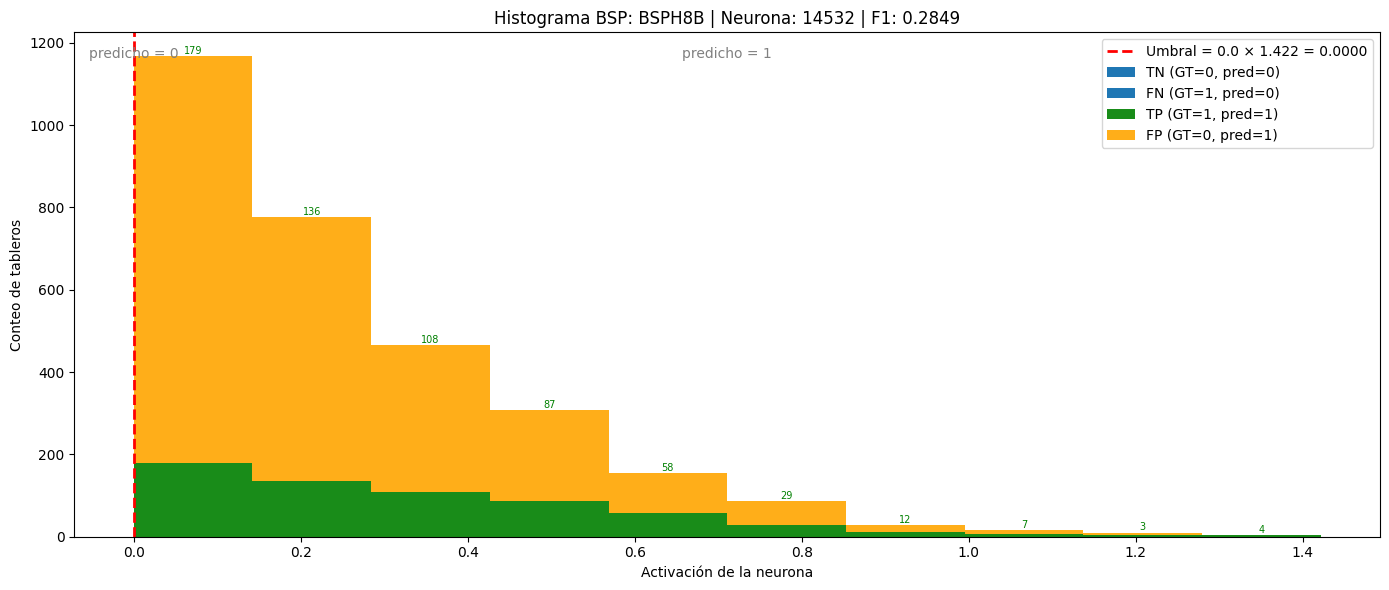


Resumen:
  TP: 623 | FP: 2395
  TN: 8049 | FN: 733
  F1: 0.2849


In [97]:
# >>> CAMBIA AQUÍ LA BSP QUE QUIERES VISUALIZAR <
import matplotlib.pyplot as plt
plot_bsp_histogram(
    BSP_HISTOGRAMA       = "BSPH8B",
    sae_features         = sae_features,
    bsp_pieces_names     = bsp_pieces_names,
    bsp_pieces_gt_tensor = bsp_pieces_gt_tensor,
    best_features        = best_features,
    best_thresholds      = best_thresholds,
    best_f1s             = best_f1s,
    n_bins               = 10
)

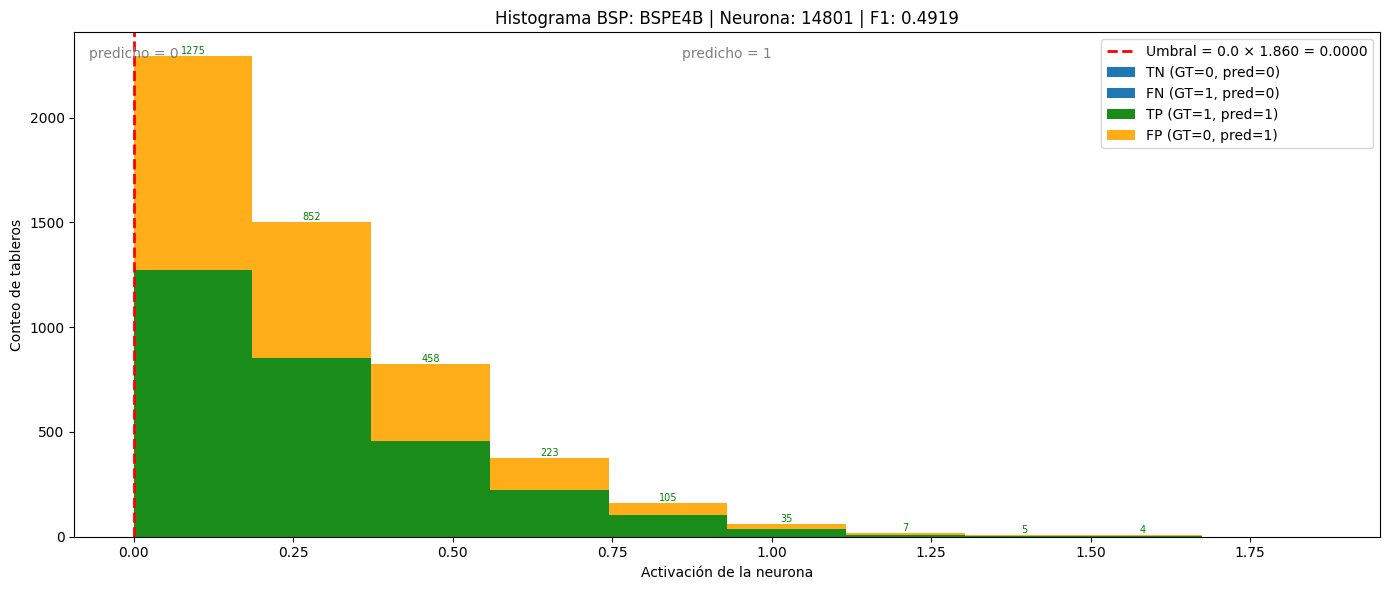


Resumen:
  TP: 2964 | FP: 2284
  TN: 2712 | FN: 3840
  F1: 0.4919


In [98]:
# >>> CAMBIA AQUÍ LA BSP QUE QUIERES VISUALIZAR <
plot_bsp_histogram(
    BSP_HISTOGRAMA       = "BSPE4B",
    sae_features         = sae_features,
    bsp_pieces_names     = bsp_pieces_names,
    bsp_pieces_gt_tensor = bsp_pieces_gt_tensor,
    best_features        = best_features,
    best_thresholds      = best_thresholds,
    best_f1s             = best_f1s,
    n_bins               = 10
)

### 8. Guardar Resultados

In [99]:
# Guardar resultados en el directorio de métricas del experimento
results = {
    'coverage': coverage,
    'best_f1s': best_f1s,
    'best_features': best_features,
    'best_thresholds': best_thresholds,
    'bsp_names': bsp_pieces_names,
    'execution_time_seconds': elapsed_time
}

metrics_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)
output_path = metrics_dir / "coverage_results.npz"
np.savez(output_path, **results)

print(f" Resultados guardados en:")
print(f"  {output_path}")

 Resultados guardados en:
  c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\200games\ex4\metrics\coverage_results.npz


### 9. Generar PDF con Quarto

In [100]:
import subprocess

# Guardar PDF en el mismo directorio que el .npz (metrics/)
pdf_dir = get_metrics_dir(
    NAMING_META['experiment_base_path'],
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    extras_id=extras_id
)

pdf_name = get_report_name(
    NAMING_META['variante'],
    NAMING_META['tecnica'],
    NAMING_META['capa'],
    NAMING_META['juegos'],
    'coverage',
    extras_id=extras_id
)

notebook_name = 'coverage_gpu_optimized.ipynb'
output_path = pdf_dir / pdf_name

print(f' Generando PDF con Quarto...')
print(f' Archivo de salida: {output_path}')

# Quarto no acepta rutas en --output, solo nombre de archivo
# Se usa --output-dir para el directorio y --output solo para el nombre
result = subprocess.run(
    f'quarto render {notebook_name} --to pdf --output-dir "{pdf_dir}" --output {pdf_name}',
    shell=True,
    capture_output=True,
    text=True
)

if result.returncode == 0:
    print(f' PDF generado exitosamente: {output_path}')
else:
    print(f' Error al generar PDF:')
    print(result.stderr)

 Generando PDF con Quarto...
 Archivo de salida: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\200games\ex4\metrics\sae_standard_p-annealing_l6_200g_ex4_coverage.pdf
 PDF generado exitosamente: c:\Users\Esposa\Documents\Repos\othello_world\sae\experiments\layer_06\sae_standard\sae_p-annealing_standard\200games\ex4\metrics\sae_standard_p-annealing_l6_200g_ex4_coverage.pdf
